In [2]:
import numpy as np
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from bluepysnap import Circuit
from bluepysnap.bbp import Cell

# CircuitPath = 'O1_data_physiology/' # edges files not inclued in https://github.com/FernandoSBorges/

CircuitPath = 'O1_data_physiology/'
MorphologyPath = CircuitPath + 'morphologies/ascii/'
CellLibraryFile = CircuitPath + 'S1nonbarrel_neurons/nodes.h5'
METypePath = CircuitPath + 'emodels_hoc/'

lst_properties = [ 'etype', 'exc_mini_frequency', 'inh_mini_frequency', 'layer', 'me_combo', 'model_template', 'model_type', 'morph_class', 'morphology', 'mtype', 
                  'orientation_w', 'orientation_x', 'orientation_y', 'orientation_z', 'population', 'region', 'synapse_class', '@dynamics:holding_current', 
                  '@dynamics:input_resistance', '@dynamics:resting_potential', '@dynamics:threshold_current', 'x', 'y', 'z']

circuit_path = CircuitPath + 'circuit_config.json'
circuit = Circuit(circuit_path)

cells = circuit.nodes["S1nonbarrel_neurons"]

nodesinfo = cells.get()

def distance3D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2)+np.power(nodesinfo['z'][gidpre]-nodesinfo['z'][gidpost],2))

def distance2D(gidpre,gidpost):
    return np.sqrt(np.power(nodesinfo['x'][gidpre]-nodesinfo['x'][gidpost],2)+np.power(nodesinfo['y'][gidpre]-nodesinfo['y'][gidpost],2))

def distance2Dmean(gidpre, mean_x, mean_y):
    return np.sqrt(np.power(nodesinfo['x_new'][gidpre]-mean_x,2)+np.power(nodesinfo['y_new'][gidpre]-mean_y,2))


mtypes = sorted(cells.property_values(Cell.MTYPE))

i = 0
mntypes = {}
for mn in sorted(mtypes):
    mntypes[mn] = i
    i+=1

print(mntypes)

{'L1_DAC': 0, 'L1_HAC': 1, 'L1_LAC': 2, 'L1_NGC-DA': 3, 'L1_NGC-SA': 4, 'L1_SAC': 5, 'L23_BP': 6, 'L23_BTC': 7, 'L23_CHC': 8, 'L23_DBC': 9, 'L23_LBC': 10, 'L23_MC': 11, 'L23_NBC': 12, 'L23_NGC': 13, 'L23_SBC': 14, 'L2_IPC': 15, 'L2_TPC:A': 16, 'L2_TPC:B': 17, 'L3_TPC:A': 18, 'L3_TPC:C': 19, 'L4_BP': 20, 'L4_BTC': 21, 'L4_CHC': 22, 'L4_DBC': 23, 'L4_LBC': 24, 'L4_MC': 25, 'L4_NBC': 26, 'L4_NGC': 27, 'L4_SBC': 28, 'L4_SSC': 29, 'L4_TPC': 30, 'L4_UPC': 31, 'L5_BP': 32, 'L5_BTC': 33, 'L5_CHC': 34, 'L5_DBC': 35, 'L5_LBC': 36, 'L5_MC': 37, 'L5_NBC': 38, 'L5_NGC': 39, 'L5_SBC': 40, 'L5_TPC:A': 41, 'L5_TPC:B': 42, 'L5_TPC:C': 43, 'L5_UPC': 44, 'L6_BP': 45, 'L6_BPC': 46, 'L6_BTC': 47, 'L6_CHC': 48, 'L6_DBC': 49, 'L6_HPC': 50, 'L6_IPC': 51, 'L6_LBC': 52, 'L6_MC': 53, 'L6_NBC': 54, 'L6_NGC': 55, 'L6_SBC': 56, 'L6_TPC:A': 57, 'L6_TPC:C': 58, 'L6_UPC': 59}


## Select nodes to simulate

In [3]:
f = open('node_sets.json') 
node_sets = json.load(f) 

mean_x, mean_y = np.mean(nodesinfo['x_new']), np.mean(nodesinfo['y_new'])
node_gid = [] 
nodepremtype_new = []    
mtype_new = []     


node_gid = []
hoclist = []
Morpholist = []
node_threshold_current = []
node_holding_current = []
hex = 'hex0'
#[139867, 141213, 141369, 133426, 135956, 137858, 114264, 114284, 115007]
# for gid in node_sets['hex0']['node_id']:
# for gid in [141369, 129252, 133426, 114284]:
for gid in node_sets['hex0']['node_id']: 
    if 'L4_' in nodesinfo['mtype'][gid] and distance2Dmean(gid, mean_x, mean_y) > 0.0 and distance2Dmean(gid, mean_x, mean_y) < 50.0 and 'EXC' in nodesinfo['synapse_class'][gid]:  
        nodepremtype_new.append(mntypes[nodesinfo['mtype'][gid]])
        if nodesinfo['mtype'][gid] not in mtype_new:
            mtype_new.append(nodesinfo['mtype'][gid])

        print(len(node_gid),gid,nodesinfo['synapse_class'][gid],nodesinfo['mtype'][gid],nodesinfo['model_template'][gid],nodesinfo['morphology'][gid],hex,distance2Dmean(gid, mean_x, mean_y))
        current1 = cells.get(gid,['@dynamics:threshold_current']).values[0]
        holding_current1 = cells.get(gid,['@dynamics:holding_current']).values[0]
        # print("%d %.5f %.5f" % (gid,current1,holding_current1))
        node_gid.append(gid)
        hoclist.append(nodesinfo['model_template'][gid][4:])
        Morpholist.append(nodesinfo['morphology'][gid])
        node_threshold_current.append(current1)
        node_holding_current.append(holding_current1)


0 109126 EXC L4_UPC hoc:cADpyr_L4TPC dend-C180997A-P3_axon-C031097B-P3 hex0 7.651331885081482
1 109170 EXC L4_UPC hoc:cADpyr_L4TPC dend-rp120803_P_1_idB_axon-RatRH2_161012_neg04_15_-_Scale_x1.000_y0.950_z1.000_-_Clone_0 hex0 47.60050476436484
2 109310 EXC L4_UPC hoc:cADpyr_L4TPC dend-rat_20140221_RH3_cell1_axon-vd100621_idC_-_Scale_x1.000_y0.950_z1.000 hex0 34.48443084301747
3 109354 EXC L4_UPC hoc:cADpyr_L4UPC dend-rp120723_L4-2_idG_axon-vd100621_idA_-_Scale_x1.000_y1.050_z1.000_-_Clone_0 hex0 20.351223944318416
4 109439 EXC L4_UPC hoc:cADpyr_L4UPC dend-rat_20151214_E2_LH4_cell1_axon-rp101228_L5-4_idC_-_Scale_x1.000_y0.975_z1.000 hex0 45.295711055422984
5 109632 EXC L4_UPC hoc:cADpyr_L4TPC dend-rp120608_P_3_idB_axon-vd110125B_INT_idA_-_Scale_x1.000_y1.050_z1.000 hex0 13.417897335385158
6 109685 EXC L4_UPC hoc:cADpyr_L4TPC dend-C010398B-P3_axon-rp120722_L4-1_idF_-_Scale_x1.000_y0.975_z1.000 hex0 44.2256476306792
7 109872 EXC L4_UPC hoc:cADpyr_L4UPC dend-rp100427-123_idC_axon-vd110125B_

# NetPyNE

In [4]:
from netpyne import specs, sim   

# Network parameters
netParams = specs.NetParams()  # object of class NetParams to store the network parameters

In [5]:
cellName_list = {}
cellName_list2 = []
gid_list = {}

Epops = []
Ipops = []

cellName_list2 = []

for gid in node_gid:

    cellName = nodesinfo['mtype'][gid] + '_' + nodesinfo['etype'][gid]
        
    cellName_list2.append(cellName)
    
    cellName_list[gid] = cellName + '_' + str(len(cellName_list2)-1)
    gid_list[cellName + '_' + str(len(cellName_list2)-1)] = gid
    
    print('%s %s %s 1 1 %d' % (cellName + '_' + str(len(cellName_list2)-1),nodesinfo['mtype'][gid],nodesinfo['etype'][gid],gid))

    if 'cADpyr' in cellName:
        Epops.append(cellName + '_' + str(len(cellName_list2)-1))
    else:
        Ipops.append(cellName + '_' + str(len(cellName_list2)-1))

L4_UPC_cADpyr_0 L4_UPC cADpyr 1 1 109126
L4_UPC_cADpyr_1 L4_UPC cADpyr 1 1 109170
L4_UPC_cADpyr_2 L4_UPC cADpyr 1 1 109310
L4_UPC_cADpyr_3 L4_UPC cADpyr 1 1 109354
L4_UPC_cADpyr_4 L4_UPC cADpyr 1 1 109439
L4_UPC_cADpyr_5 L4_UPC cADpyr 1 1 109632
L4_UPC_cADpyr_6 L4_UPC cADpyr 1 1 109685
L4_UPC_cADpyr_7 L4_UPC cADpyr 1 1 109872
L4_UPC_cADpyr_8 L4_UPC cADpyr 1 1 110044
L4_UPC_cADpyr_9 L4_UPC cADpyr 1 1 110155
L4_UPC_cADpyr_10 L4_UPC cADpyr 1 1 110359
L4_UPC_cADpyr_11 L4_UPC cADpyr 1 1 110557
L4_UPC_cADpyr_12 L4_UPC cADpyr 1 1 110595
L4_UPC_cADpyr_13 L4_UPC cADpyr 1 1 110675
L4_UPC_cADpyr_14 L4_UPC cADpyr 1 1 111043
L4_UPC_cADpyr_15 L4_UPC cADpyr 1 1 111183
L4_UPC_cADpyr_16 L4_UPC cADpyr 1 1 111324
L4_UPC_cADpyr_17 L4_UPC cADpyr 1 1 111850
L4_UPC_cADpyr_18 L4_UPC cADpyr 1 1 112199
L4_UPC_cADpyr_19 L4_UPC cADpyr 1 1 112410
L4_UPC_cADpyr_20 L4_UPC cADpyr 1 1 112417
L4_UPC_cADpyr_21 L4_UPC cADpyr 1 1 112501
L4_UPC_cADpyr_22 L4_UPC cADpyr 1 1 112531
L4_UPC_cADpyr_23 L4_UPC cADpyr 1 1 112935
L4

In [6]:
cellsList = {}

for cellName in gid_list.keys():
    # try:
        if not cellName.startswith('L4_SSC'):
                continue

    
        gid = gid_list[cellName]

        MorphoName = nodesinfo['morphology'][gid] + '.asc'

        hocName = nodesinfo['model_template'][gid][4:]  

        MorphologyPath = 'O1_data_physiology/morphologies/ascii'
        
        # MorphoName = nodesinfo['morphology'][gid]+"_gid"+str(gid)+".asc"

        print(cellName,hocName)
            
        cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
            conds={'cellType': cellName, 'cellModel': 'HH_full'},
            fileName='O1_data_physiology/emodels_hoc/' + hocName + '.hoc',
            cellName=hocName,
            cellInstance = False,
            cellArgs=[gid, MorphologyPath, MorphoName])
        
        # netParams.saveCellParamsRule(label=cellName, fileName=cellName+'_BBP_cellParams.json')

        cellsList[cellName] = [{'x': nodesinfo['x'][gid], 'y': nodesinfo['y'][gid], 'z': nodesinfo['z'][gid]}]
        # cellsList[cellName] = [{'x': nodesinfo['x'][gid] - 3000.0, 'y': nodesinfo['y'][gid] + 2000.0, 'z': nodesinfo['z'][gid] + 3500.0}]

        cellMe = cellName
        
        axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, soma_pt3d_diam =  netParams.cellParams[cellMe]['secs']['soma_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam'] = 1.0
        # netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L'] = 30.0

        axon_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['diam']
        axon_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'] = [(axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L/2.0, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L, axon_pt3d_z, axon_pt3d_diam)]



        axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon_0_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam'] = 0.5
        # netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L'] = 30.0

        axon1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['diam']
        axon1_pt3d_L =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['L']

        netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'] = [(axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L/2.0, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L, axon1_pt3d_z, axon1_pt3d_diam)] 


                    
        myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, axon_1_pt3d_diam =  netParams.cellParams[cellMe]['secs']['axon_1']['geom']['pt3d'][-1]

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam'] = 0.5
        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L'] = 100.0

        myelin_pt3d_diam =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['diam']
        myelin_pt3d_L =  netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['L']

        netParams.cellParams[cellMe]['secs']['myelin_0']['geom']['pt3d'] = [(myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L/2.0, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L, myelin_pt3d_z, myelin_pt3d_diam)] 

    # except:
    #     pass        

# cellsList

L4_SSC_cADpyr_177 cADpyr_L4UPC
L4_SSC_cADpyr_178 cADpyr_L4TPC
L4_SSC_cADpyr_179 cADpyr_L4UPC
L4_SSC_cADpyr_180 cADpyr_L4UPC
L4_SSC_cADpyr_181 cADpyr_L4UPC
L4_SSC_cADpyr_182 cADpyr_L4TPC
L4_SSC_cADpyr_183 cADpyr_L4UPC
L4_SSC_cADpyr_184 cADpyr_L4UPC
L4_SSC_cADpyr_185 cADpyr_L4UPC
L4_SSC_cADpyr_186 cADpyr_L4TPC
L4_SSC_cADpyr_187 cADpyr_L4TPC
L4_SSC_cADpyr_188 cADpyr_L4UPC
L4_SSC_cADpyr_189 cADpyr_L4UPC
L4_SSC_cADpyr_190 cADpyr_L4TPC
L4_SSC_cADpyr_191 cADpyr_L4UPC
L4_SSC_cADpyr_192 cADpyr_L4UPC
L4_SSC_cADpyr_193 cADpyr_L4UPC
L4_SSC_cADpyr_194 cADpyr_L4UPC
L4_SSC_cADpyr_195 cADpyr_L4TPC
L4_SSC_cADpyr_196 cADpyr_L4UPC
L4_SSC_cADpyr_197 cADpyr_L4TPC
L4_SSC_cADpyr_198 cADpyr_L4TPC
L4_SSC_cADpyr_199 cADpyr_L4UPC


In [7]:
layer = {'1':[0.0, 0.079], '2': [0.079,0.151], '3': [0.151,0.320], '23': [0.079,0.320], '4':[0.320,0.412], '5': [0.412,0.664], '6': [0.664,1.0], 
'longS1': [2.2,2.3], 'longS2': [2.3,2.4]}  # normalized layer boundaries

#Th pop
ymin={'ss_RTN_o': 1000+1688, 'ss_RTN_m': 1000+1766, 'ss_RTN_i': 1000+1844, 'VPL_sTC': 1000+2000, 'VPM_sTC': 1000+2156, 'POm_sTC_s1': 1000+2312}
ymax={'ss_RTN_o': 1000+1766, 'ss_RTN_m': 1000+1844, 'ss_RTN_i': 1000+2000, 'VPL_sTC': 1000+2156, 'VPM_sTC': 1000+2312, 'POm_sTC_s1': 1000+2624}

#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 30.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 1500.0 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 30.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
   
netParams.defaultThreshold = -20.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
netParams.defaultDelay = 0.1 # default conn delay (ms)
netParams.propVelocity = 300.0 #  300 μm/ms (Stuart et al., 1997)
netParams.scaleConnWeightNetStims = 0.001  # weight conversion factor (from nS to uS)
    
#------------------------------------------------------------------------------
# load data from S1 Raster
#------------------------------------------------------------------------------
# netParams.cellParams[cellName]
for cellName in netParams.cellParams.keys():    
    netParams.popParams[cellName] = {'cellType': cellName, 'cellsList': cellsList[cellName], 'cellModel': 'HH_full'}

In [8]:
#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg = specs.SimConfig()					            # object of class SimConfig to store simulation configuration

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 400 ## Duration of the sim, in ms  
cfg.dt = 0.025
cfg.seeds = {'cell': 4321, 'conn': 4321, 'stim': 1000, 'loc': 4321} 
cfg.hParams = {'celsius': 34, 'v_init': -84.0}  
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True  
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording 
#--------------------------------------------------------------------------
cfg.recordCells = list(netParams.popParams.keys())
# cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'}}  ## Dict with traces to record  
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_myelin_0': {'sec':'myelin_0', 'loc':0.5, 'var':'v'},
                    # 'V_axon_15': {'sec':'axon_15', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_47': {'sec':'apic_47', 'loc':0.5, 'var':'v'},       
                    # 'V_apic_64': {'sec':'apic_64', 'loc':0.5, 'var':'v'},
                    # 'V_apic_86': {'sec':'apic_86', 'loc':0.5, 'var':'v'},           
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},       
                    # 'V_dend_15': {'sec':'dend_15', 'loc':0.5, 'var':'v'},
                    }
cfg.recordStim = False			
cfg.recordTime = True  		
cfg.recordStep = 0.025       

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'exploration/data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = False	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##  
cfg.gatherOnlySimData = False	##  
cfg.saveCellSecs = True			
cfg.saveCellConns = True	

#------------------------------------------------------------------------------
# Analysis and plotting 
# ------------------------------------------------------------------------------
# cfg.analysis['plotRaster'] = {'include': cfg.S1cells, 'saveFig': True, 'showFig': False,'orderInverse': True, 'timeRange': [0,cfg.duration], 'figSize': (24,8), 'fontSize':4, 'markerSize':4, 'marker': 'o', 'dpi': 300} 
# cfg.analysis['plot2Dnet']   = {'include': ['presyn_L23_PC_cAD','presyn_L5_TTPC2_cAD', 'presyn_VPM_sTC','L23_PC_cAD','L5_TTPC2_cAD'],'saveFig': True, 'showConns': False, 'figSize': (24,24), 'view': 'xz', 'fontSize':16}   # Plot 2D cells xy
# cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'ylim': [-100,50], 'saveFig': True, 'showFig': False, 'figSize':(24,24)}

cfg.analysis['plotTraces'] = {'include': [ii for ii in range(len(node_gid))], 'oneFigPer': 'trace', 'overlay': True, 'timeRange': [0,cfg.duration], 'saveFig': False, 'showFig': True, 'figSize':(24,4)} # , 'ylim': [-90,30] Plot recorded traces for this list of cells
# cfg.analysis['plotShape'] = {'includePre':  [ii for ii in range(10)],'includePre':  [ii for ii in range(10)], 'saveFig': True, 'showFig': True, 'figSize':(12,12)}



In [255]:
#------------------------------------------------------------------------------
# ThVecStim->S1 connectivity parameters
#------------------------------------------------------------------------------
#------------------------------------------------------------------------------  
# Thalamic Cells

cfg.cellNumber = {}
cfg.popLabel = {}
cfg.popNumber = {}
 
cfg.thalamicpops = ['VPM_sTC']
cfg.cellNumber['VPM_sTC'] = 800

for mtype in cfg.thalamicpops: # No diversity
	metype = mtype
	cfg.popLabel[metype] = mtype
	cfg.popNumber[mtype] = cfg.cellNumber[metype]

## Th->S1
cfg.connect_ThVecStim_S1 = True
cfg.TC_S1 = {}
cfg.TC_S1['VPM_sTC'] = True
cfg.TC_S1_weightE = 0.0001
cfg.TC_S1_weightI = 0.0001

# J. Neurosci., June 29, 2016 • 36(26):6906 – 6916
# thalamocortical uEPSPs had several-fold larger amplitudes and faster kinetics in FS interneurons compared with excitatory neurons
# amplitude, 1.8 –13.8 vs 0.4 – 0.9 mV; 
# rise time, 0.4 – 0.8 vs 1.3–2.8 ms; 
# decay time constant, 6 –12 vs 17–36 ms
# Th -
netParams.synMechParams['AMPA_Th']             = {'mod': 'MyExp2SynBB',        'tau1': 0.05,   'tau2': 5.3, 'e': 0}
netParams.synMechParams['NMDA_Th']             = {'mod': 'MyExp2SynNMDABB',    'tau1NMDA': 15, 'tau2NMDA': 150,                'e': 0}
ESynMech_Th = ['AMPA_Th', 'NMDA_Th']

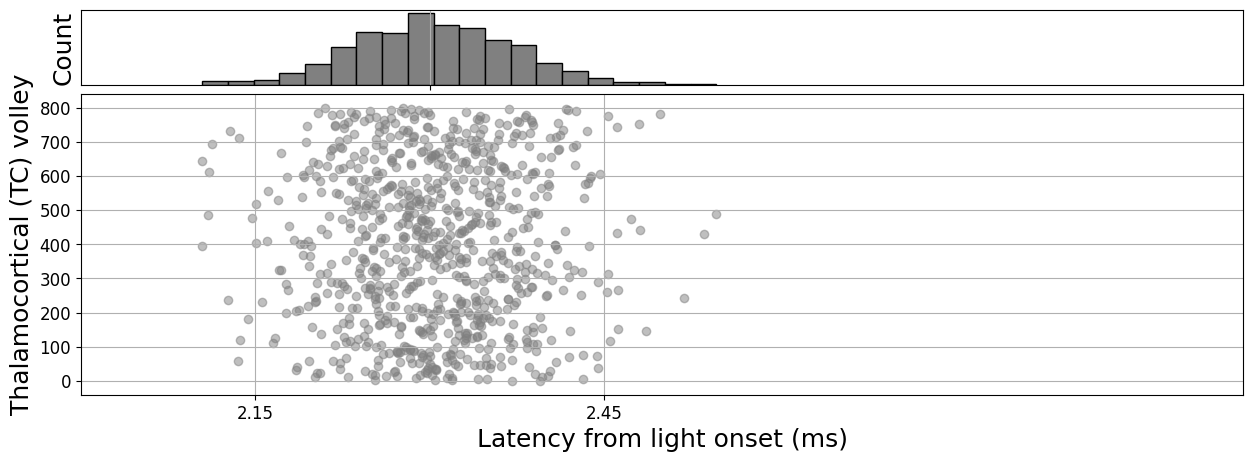

In [271]:
gaussian1 = np.random.normal(2.3, 0.07, 800)
gaussian2 = np.random.normal(6.0, 0.22, 80)
gaussian3 = np.random.normal(10.8, 0.24, 60)

gaussian = np.concatenate((gaussian1, gaussian2, gaussian3))

gaussian = gaussian1

fig = plt.figure(figsize=(15, 5))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.05)

# Histogram on top
ax_hist = fig.add_subplot(gs[0])
ax_hist.hist(gaussian, bins=20, color='gray', edgecolor='black')
ax_hist.set_xticks([])
ax_hist.set_yticks([])
ax_hist.set_ylabel('Count', size=18)
ax_hist.set_xlim(2, 3.0)
ax_hist.set_xticks([2.3])
ax_hist.grid(True)
# ax_hist.spines['bottom'].set_visible(False)

# Scatter plot below
ax_scatter = fig.add_subplot(gs[1])
ax_scatter.scatter(gaussian, np.arange(len(gaussian)), color='gray', alpha=0.5)
ax_scatter.set_xlabel('Latency from light onset (ms)', size=18)
ax_scatter.set_ylabel('Thalamocortical (TC) volley', size=18)
ax_scatter.set_xticks([0, 2.15, 2.45, 6.0, 10.8, 12])
ax_scatter.set_xlim(2, 3.0)
ax_scatter.grid(True)

plt.show()

In [272]:
# create 1 vectstim pop per cell gid
for metype in cfg.thalamicpops: # metype

    # print(metype, cfg.cellNumber[metype])
    
    cellsList = []            
    for cellLabel in range(cfg.cellNumber[metype]): # all cells in metype
        # if cellLabel < len(gaussian3):
        #     spike_times = np.array([gaussian1[cellLabel], gaussian2[cellLabel], gaussian3[cellLabel]])
        # else:
        #     spike_times = np.array([gaussian1[cellLabel], gaussian2[cellLabel]])

        # spike_times = spike_times + 300.0  # light onset at 300 ms

        spike_times = np.array(gaussian1[cellLabel:cellLabel+1]) + 300.0  # light onset at 300 ms
        cellsList.append({'cellLabel': cellLabel, 'spkTimes': list(spike_times[:1])})
        # cellsList.append({'cellLabel': cellLabel, 'spkTimes': list(spike_times[:1])})
        print(cellLabel, spike_times[:1])
        
    if np.size(cellsList) > 0:
        netParams.popParams[metype] = {'cellModel': 'VecStim', 'cellsList': cellsList}        


0 [302.39522897]
1 [302.37050701]
2 [302.30496439]
3 [302.25324714]
4 [302.31916058]
5 [302.43216916]
6 [302.34154115]
7 [302.34932846]
8 [302.314933]
9 [302.31937334]
10 [302.28861093]
11 [302.2299031]
12 [302.39661703]
13 [302.20129434]
14 [302.26254914]
15 [302.40219422]
16 [302.27193841]
17 [302.30238629]
18 [302.25326224]
19 [302.29185879]
20 [302.25066049]
21 [302.39103297]
22 [302.31626783]
23 [302.20289286]
24 [302.2974514]
25 [302.20567989]
26 [302.29641822]
27 [302.2690463]
28 [302.24464087]
29 [302.40365101]
30 [302.27043777]
31 [302.3053879]
32 [302.18536292]
33 [302.29763872]
34 [302.30522604]
35 [302.22253355]
36 [302.30449716]
37 [302.35154227]
38 [302.44485542]
39 [302.29828738]
40 [302.18554923]
41 [302.30201015]
42 [302.38509315]
43 [302.25543475]
44 [302.32460502]
45 [302.36156602]
46 [302.33841164]
47 [302.34816794]
48 [302.3433006]
49 [302.29993116]
50 [302.32149846]
51 [302.35297224]
52 [302.22294724]
53 [302.29122228]
54 [302.28488381]
55 [302.27433922]
56 [302.4

In [273]:
# netParams.popParams[metype]

In [284]:

cfg.connect_ThVecStim_S1 = True
cfg.TC_S1 = {}
cfg.TC_S1['VPM_sTC'] = True
cfg.TC_S1_weightE = 0.00025
cfg.TC_S1_weightI = 0.00025

if cfg.connect_ThVecStim_S1:

    # for post in Epops: 
    #     convergence_Th_S1['VPM_sTC']['L4_PC'] = 197
    #     convergence_Th_S1['VPM_sTC']['L4_SP'] = 197
    #     convergence_Th_S1['VPM_sTC']['L4_SS'] = 188
    #     convergence_Th_S1['VPM_sTC']['L4_INH'] = 116


    ## Connectivity rules
    synapsesperconnection_Th_S1 = 9.0
    for pre in ['VPM_sTC']:  #  
        if cfg.TC_S1[pre]:
            for post in Epops: 
                
                if 'L4_SS' in post:
                    conn_convergence = np.ceil(500/synapsesperconnection_Th_S1)
                else:
                    conn_convergence = np.ceil(450/synapsesperconnection_Th_S1)

                netParams.connParams['thal_'+pre+'_'+post] = { 
                    'preConds': {'pop': pre},  ####################################################
                    'postConds': {'pop': post},
                    'weight': cfg.TC_S1_weightE,   # synaptic weight 
                    'sec': 'all', #['basal', 'apical'], # target postsyn section
                    'delay': 0.6,
                    'synsPerConn': int(synapsesperconnection_Th_S1),                     
                    'synMech': ESynMech_Th}  

                netParams.connParams['thal_'+pre+'_'+post]['convergence'] = conn_convergence 
                # netParams.connParams['thal_'+pre+'_'+post]['convergence'] = 1 

                # if 'L4_UPC' in post:
                #     netParams.connParams['thal_'+pre+'_'+post]['weight'] = 0.000225

                # if 'L4_TPC_cADpyr_1' in post:
                #     netParams.connParams['thal_'+pre+'_'+post]['weight'] = 0.000057

                # if 'L4_TPC_cADpyr_2' in post:
                #     netParams.connParams['thal_'+pre+'_'+post]['weight'] = 0.0005


            for post in Ipops: 
                
                conn_convergence = np.ceil(350/synapsesperconnection_Th_S1)

                netParams.connParams['thal_'+pre+'_'+post] = { 
                    'preConds': {'pop': pre},  ####################################################
                    'postConds': {'pop': post},
                    'weight': cfg.TC_S1_weightI,   # synaptic weight 
                    'sec': 'somatic', # target postsyn section
                    'delay': 0.4,
                    'synsPerConn': int(synapsesperconnection_Th_S1),                     
                    'synMech': ESynMech_Th}  

                netParams.connParams['thal_'+pre+'_'+post]['convergence'] = conn_convergence 
                # netParams.connParams['thal_'+pre+'_'+post]['convergence'] = 1 

# for i,post in enumerate(Ipops):
#     netParams.connParams[post+'_'+post] = { 
#                     'preConds': {'pop': post},  ####################################################
#                     'postConds': {'pop': Ipops[2]},
#                     'weight': cfg.TC_S1_weightE,   # synaptic weight 
#                     'sec': 'basal', # target postsyn section
#                     'delay': 1.75+2.5*i,
#                     'synsPerConn': 1500,                     
#                     'synMech': ESynMech_Th}  

# print(netParams.connParams.keys())


In [285]:
sim.initialize(
    simConfig = cfg, 	
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations


Start time:  2025-10-16 17:29:08.330064


{L4_SSC_cADpyr_177: <netpyne.network.pop.Pop object at 0x72b3a6f85f70>, L4_SSC_cADpyr_178: <netpyne.network.pop.Pop object at 0x72b3aaf12c10>, L4_SSC_cADpyr_179: <netpyne.network.pop.Pop object at 0x72b39c87c940>, L4_SSC_cADpyr_180: <netpyne.network.pop.Pop object at 0x72b39c87cd90>, L4_SSC_cADpyr_181: <netpyne.network.pop.Pop object at 0x72b39c87c970>, L4_SSC_cADpyr_182: <netpyne.network.pop.Pop object at 0x72b39c87c9a0>, L4_SSC_cADpyr_183: <netpyne.network.pop.Pop object at 0x72b39c87c910>, L4_SSC_cADpyr_184: <netpyne.network.pop.Pop object at 0x72b39c87c820>, L4_SSC_cADpyr_185: <netpyne.network.pop.Pop object at 0x72b39c87cdc0>, L4_SSC_cADpyr_186: <netpyne.network.pop.Pop object at 0x72b39c87c490>, L4_SSC_cADpyr_187: <netpyne.network.pop.Pop object at 0x72b39c87cb80>, L4_SSC_cADpyr_188: <netpyne.network.pop.Pop object at 0x72b39c87caf0>, L4_SSC_cADpyr_189: <netpyne.network.pop.Pop object at 0x72b39c87cf70>, L4_SSC_cADpyr_190: <netpyne.network.pop.Pop object at 0x72b39c87cac0>, L4_SS

In [286]:
sim.net.createCells()              			# instantiate network cells based on defined populations
sim.net.connectCells()            			# create connections between cells based on params
sim.net.addStims() 							# add network stimulation
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)


Creating network of 24 cell populations on 1 hosts...
  Number of cells on node 0: 823 
  Done; cell creation time = 0.14 s.
Making connections...
  Number of connections on node 0: 1288 
  Number of synaptic contacts on node 0: 23184 
  Done; cell connection time = 0.40 s.
  Number of stims on node 0: 0 
  Done; cell stims creation time = 0.00 s.
Recording 23 traces of 1 types on node 0


{spkt: Vector[230315], spkid: Vector[230316], V_soma: {cell_0: Vector[230340], cell_1: Vector[230341], cell_2: Vector[230342], cell_3: Vector[230343], cell_4: Vector[230344], cell_5: Vector[230345], cell_6: Vector[230346], cell_7: Vector[230347], cell_8: Vector[230348], cell_9: Vector[230349], cell_10: Vector[230350], cell_11: Vector[230351], cell_12: Vector[230352], cell_13: Vector[230353], cell_14: Vector[230354], cell_15: Vector[230355], cell_16: Vector[230356], cell_17: Vector[230357], cell_18: Vector[230358], cell_19: Vector[230359], cell_20: Vector[230360], cell_21: Vector[230361], cell_22: Vector[230362]}, t: Vector[230363], _repr_mimebundle_: {}}

In [287]:
sim.runSim()                      			# run parallel Neuron simulation  

0.0s

Running simulation using NEURON for 400.0 ms...
0.1s
0.2s
0.3s
0.4s
  Done; run time = 26.45 s; real-time ratio: 0.02.


In [288]:
sim.gatherData();                  			# gather spiking data and cell info from each node


Gathering data...
  Done; gather time = 0.23 s.

Analyzing...
  Cells: 823
  Connections: 1288 (1.57 per cell)
  Synaptic contacts: 23184 (28.17 per cell)
  Spikes: 952 (2.89 Hz)
  Simulated time: 0.4 s; 1 workers
  Run time: 26.45 s
   L4_SSC_cADpyr_177 : 17.500 Hz
   L4_SSC_cADpyr_178 : 17.500 Hz
   L4_SSC_cADpyr_179 : 12.500 Hz
   L4_SSC_cADpyr_180 : 20.000 Hz
   L4_SSC_cADpyr_181 : 17.500 Hz
   L4_SSC_cADpyr_182 : 17.500 Hz
   L4_SSC_cADpyr_183 : 20.000 Hz
   L4_SSC_cADpyr_184 : 10.000 Hz
   L4_SSC_cADpyr_185 : 15.000 Hz
   L4_SSC_cADpyr_186 : 15.000 Hz
   L4_SSC_cADpyr_187 : 20.000 Hz
   L4_SSC_cADpyr_188 : 17.500 Hz
   L4_SSC_cADpyr_189 : 20.000 Hz
   L4_SSC_cADpyr_190 : 10.000 Hz
   L4_SSC_cADpyr_191 : 17.500 Hz
   L4_SSC_cADpyr_192 : 20.000 Hz
   L4_SSC_cADpyr_193 : 17.500 Hz
   L4_SSC_cADpyr_194 : 17.500 Hz
   L4_SSC_cADpyr_195 : 15.000 Hz
   L4_SSC_cADpyr_196 : 15.000 Hz
   L4_SSC_cADpyr_197 : 17.500 Hz
   L4_SSC_cADpyr_198 : 12.500 Hz
   L4_SSC_cADpyr_199 : 17.500 Hz
   VPM

In [289]:
# Calcular o firing rate
spk_times = sim.simData['spkt']  # Tempos de spikes
spk_ids = sim.simData['spkid']  # IDs dos neurônios

steps, rates = np.unique(spk_ids, return_counts=True)
# steps, rates/0.6

In [290]:
sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
# sim.analysis.plotData()         			# plot spike raster etc

[]

Preparing spike data...
Plotting raster...


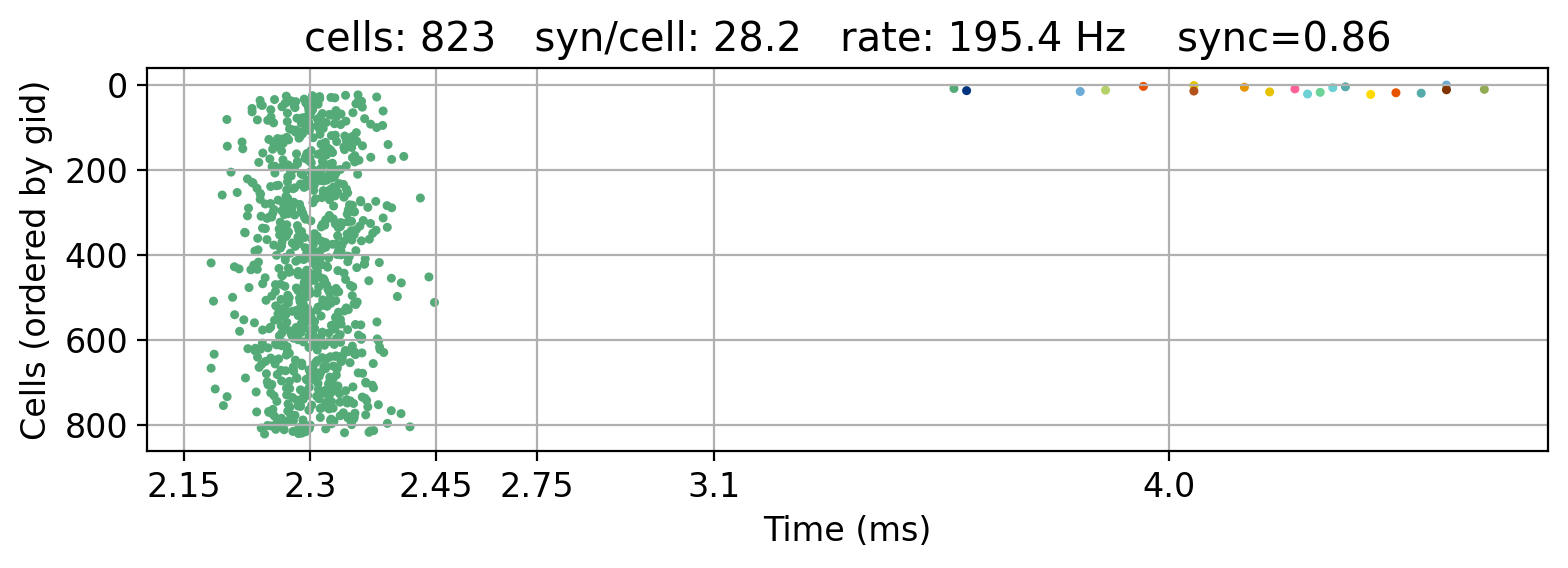

In [298]:
timeRange = [299.9,305]
sim.analysis.plotRaster(**{'saveFig': False, 'showFig': False, 'popRates': True,'orderInverse': True, 'labels': None,
                           'timeRange': timeRange, 'figSize': (8,3), 'fontSize':8, 'lw': 1, 'markerSize':1, 'marker': 'o', 'dpi': 200})
# plt.xticks(np.linspace(500.5,511.5,23))
# plt.xticks(299.9+np.array([0.1, 0.6, 2.9, 5.4, 7.5, 10,12]),np.array([0, 0.6, 2.9, 5.4, 7.5, 10, 12]))
plt.xticks(300+np.array([2.05, 2.3, 2.55, 2.75, 3.1, 4.0]),np.array([2.15, 2.3, 2.45, 2.75, 3.1, 4.0]))
plt.grid(True)
plt.show()

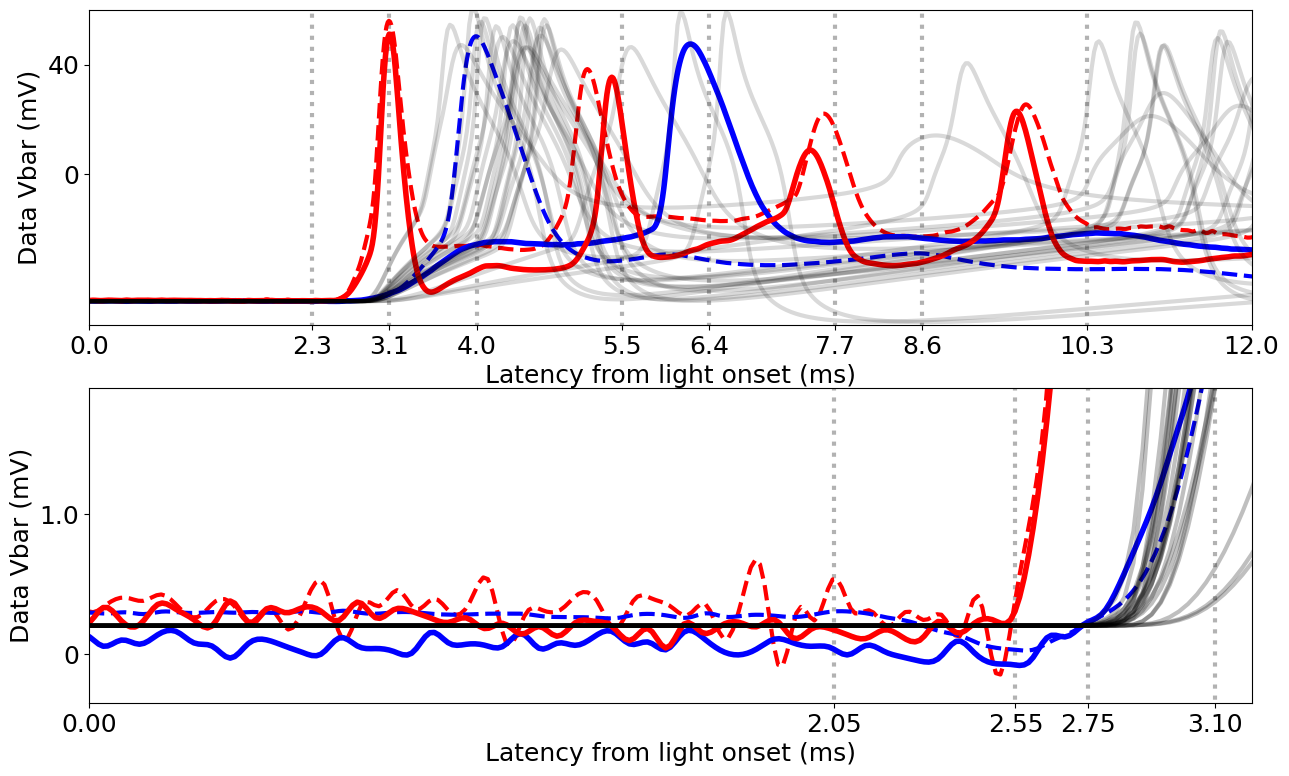

In [297]:
plt.figure(figsize=(15, 9))

plt.subplot(2, 1, 1)
plt.vlines(x=[2.3, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3],ymin=-80, ymax=40, colors='k', linestyles='dotted', linewidth=3,  alpha=0.3)
plt.plot(t_highres2-1.2, v_highres2+4-3.7, color='red', linewidth=3, linestyle='--')
plt.plot(t_highres4-0.5, v_highres4+3-3.7, color='blue', linewidth=3, linestyle='--')
plt.plot(t_highres3-1.01, v_highres3+10, color='blue', linewidth=4)
plt.plot(t_highres-1.01, v_highres+3, color='red', linewidth=4)
plt.ylabel('Data Vbar (mV)', size=18)
plt.xlim(0.0, 12)
plt.ylim(-75.0, 40)
plt.xticks([0, 2.3, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3, 12], size=18);
plt.xlabel('Latency from light onset (ms)', size=18);
plt.yticks([-20,20], [0,40], size=18);
for cell in sim.simData['V_soma'].keys():
    if 'cell' in cell:   
        try:
            plt.plot(sim.simData['t']-300., sim.simData['V_soma'][cell]-sim.simData['V_soma'][cell][12000]-66.4, color='k', linewidth=3, alpha=0.15)
        except:
            print(cell) 
            pass
# plt.ylim(-67., -65.5);
plt.subplot(2, 1, 2)
plt.vlines(x=[2.05, 2.55, 2.75, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3],ymin=-80, ymax=40, colors='k', linestyles='dotted', linewidth=3,  alpha=0.3)
plt.plot(t_highres2-1.2, v_highres2+4-3.7, color='red', linewidth=3, linestyle='--')
plt.plot(t_highres4-0.5, v_highres4+3-3.7, color='blue', linewidth=3, linestyle='--')
plt.plot(t_highres3-1.01, v_highres3+10, color='blue', linewidth=4)
plt.plot(t_highres-1.01, v_highres+3, color='red', linewidth=4)
plt.ylabel('Data Vbar (mV)', size=18)
plt.xlim(0.0, 3.2)
plt.xticks([0,2.05, 2.55, 2.75, 3.1], size=18);
plt.ylim(-66.75, -64.5);
plt.yticks([-66.4, -65.4],[0,1.0], size=18);
plt.xlabel('Latency from light onset (ms)', size=18);
for cell in sim.simData['V_soma'].keys():
    if 'cell' in cell:   
        try:
            plt.plot(sim.simData['t']-300., sim.simData['V_soma'][cell]-sim.simData['V_soma'][cell][12000]-66.2, color='k', linewidth=3, alpha=0.25)
        except:
            print(cell) 
            pass

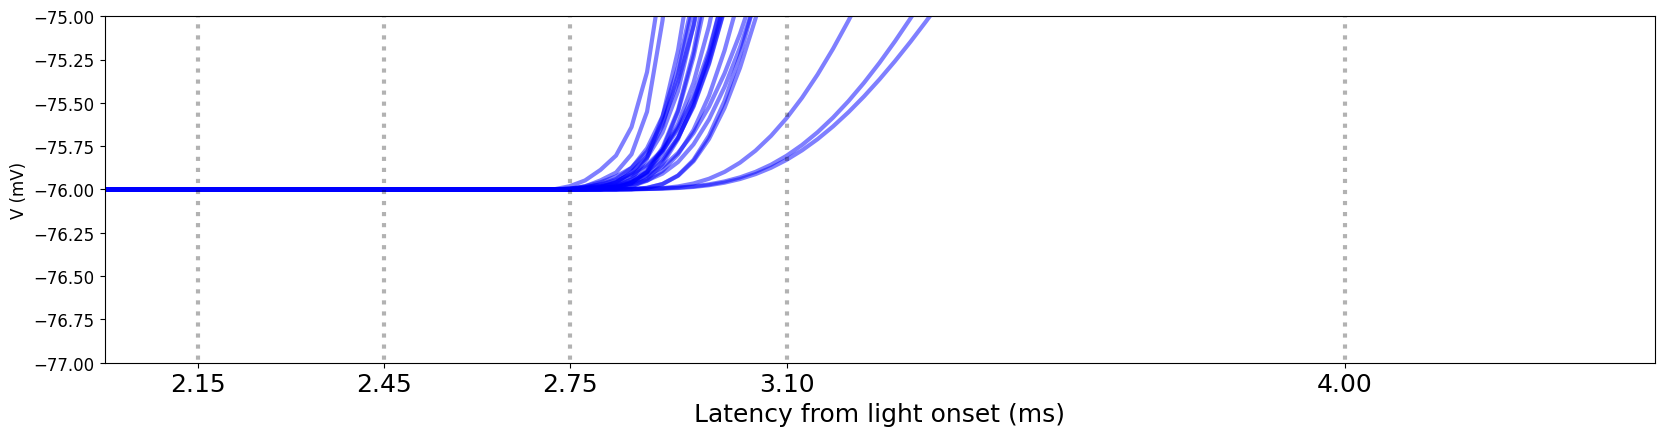

In [293]:
fig = plt.figure(figsize=(20, 4.5))
# plt.vlines(x=[0,0.3,1.45,3.75],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
for cell in sim.simData['V_soma'].keys():
    if 'cell' in cell:   
        try:
            plt.plot(sim.simData['t']-300., sim.simData['V_soma'][cell]-sim.simData['V_soma'][cell][12000]-76, color='blue', linewidth=3, alpha=0.5)
        except:
            print(cell) 
            pass
plt.xlim(2.0, 4.5)
plt.ylim(-77, -75)
plt.ylabel('V (mV)')
# plt.vlines(x=np.array([2.05, 2.55, 2.75, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3]),ymin=-80, ymax=40, colors='k', linestyles='dotted', linewidth=3,  alpha=0.3)
plt.xlabel('Latency from light onset (ms)', size=18);
# plt.xticks(np.array([0, 2.05, 2.55, 2.75, 3.1, 4.0, 5.5, 6.4, 7.7, 8.6, 10.3, 15]), size=18);
plt.vlines(x=np.array([2.15, 2.45, 2.75, 3.1, 4.0]),ymin=-80, ymax=40, colors='k', linestyles='dotted', linewidth=3,  alpha=0.3)
plt.xticks(np.array([2.15, 2.45, 2.75, 3.1, 4.0]), size=18);

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

excel_file_path = "Spike_trains_steps_L4_elife_Aric.xlsx"

df_rs = pd.read_excel(excel_file_path, sheet_name="RS")
df_fs = pd.read_excel(excel_file_path, sheet_name="FS")
df_rip = pd.read_excel(excel_file_path, sheet_name="Ripplets")
df_rip2 = pd.read_excel(excel_file_path, sheet_name="Ripplets2")

print("DataFrame for sheet 'RS':")
print(df_rs.head())
print("\nDataFrame for sheet 'FS':")
print(df_fs.head())
print("\nDataFrame for sheet 'Ripplets':")
print(df_rip.head())
print("\nDataFrame for sheet 'Ripplets2':")
print(df_rip2.head())

DataFrame for sheet 'RS':
     ms    -100      60      70     100     200
0  0.00 -71.045 -70.778 -69.588 -71.480 -70.015
1  0.05 -71.060 -70.686 -69.626 -71.648 -70.061
2  0.10 -71.037 -70.587 -69.618 -71.510 -70.007
3  0.15 -71.091 -70.686 -69.649 -71.503 -69.984
4  0.20 -71.053 -70.625 -69.687 -71.617 -70.061

DataFrame for sheet 'FS':
     ms    -320     240     280     400     600
0  0.00 -68.466 -68.558 -68.886 -69.473 -69.489
1  0.05 -68.390 -68.687 -68.848 -69.450 -69.427
2  0.10 -68.336 -68.703 -68.802 -69.550 -69.359
3  0.15 -68.466 -68.695 -68.871 -69.389 -69.328
4  0.20 -68.474 -68.550 -68.932 -69.679 -69.427

DataFrame for sheet 'Ripplets':
   031820_DFI_P41  FS 5 ms stim  Field  102920_DFI_P36  RS 2 ms stim  Field.1
0            0.00       -66.475 -0.004            0.00       -65.420   -0.046
1            0.05       -66.322 -0.011            0.05       -65.404    0.010
2            0.10       -66.269  0.011            0.10       -65.414    0.074
3            0.15       -6

In [102]:
sim.simData['V_soma']['cell_1']

Vector[182172]

(298.0, 320.0)

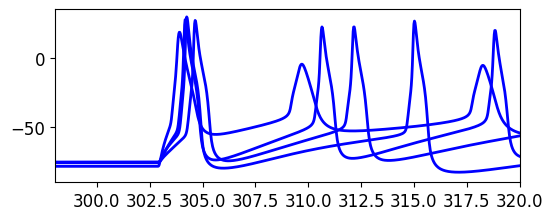

In [103]:
fig = plt.figure(figsize=(6, 2.25))
plt.plot(sim.simData['t'], sim.simData['V_soma']['cell_0']+0.0, color='blue', linewidth=2)
plt.plot(sim.simData['t'], sim.simData['V_soma']['cell_1']+0.0, color='blue', linewidth=2)
plt.plot(sim.simData['t'], sim.simData['V_soma']['cell_2']+0, color='blue', linewidth=2)
plt.plot(sim.simData['t'], sim.simData['V_soma']['cell_3']+0.0, color='blue', linewidth=2)
plt.xlim(298, 320)
# plt.ylim(-11.5, 24)

In [104]:
from scipy.interpolate import interp1d

# -------------------------------------------------------------------------------- #
# Original time and voltage
t_orig = df_rip2['042021'].values
v_orig = df_rip2['FS 2 ms stim IC'].values

# Create new time array with double the number of points (higher resolution)
t_highres = np.linspace(t_orig[0], t_orig[-1], 4 * len(t_orig) - 1)

# Interpolate using cubic interpolation
interp_func = interp1d(t_orig, v_orig, kind='cubic')
v_highres = interp_func(t_highres)

# -------------------------------------------------------------------------------- #
t_orig2 = df_rip['031820_DFI_P41'].values
v_orig2 = df_rip['FS 5 ms stim'].values

# Create new time array with double the number of points (higher resolution)
t_highres2 = np.linspace(t_orig2[0], t_orig2[-1], 4 * len(t_orig2) - 1)
# Interpolate using cubic interpolation
interp_func2 = interp1d(t_orig2, v_orig2, kind='cubic')
v_highres2 = interp_func2(t_highres2)   

# -------------------------------------------------------------------------------- #
# Original time and voltage
t_orig3 = df_rip2['042021'].values
v_orig3 = df_rip2['RS 2 ms stim IC'].values

# Create new time array with double the number of points (higher resolution)
t_highres3 = np.linspace(t_orig3[0], t_orig3[-1], 4 * len(t_orig3) - 1)
# Interpolate using cubic interpolation
interp_func3 = interp1d(t_orig3, v_orig3, kind='cubic')
v_highres3 = interp_func3(t_highres3)   

# -------------------------------------------------------------------------------- #

t_orig4 = df_rip['102920_DFI_P36'].values
v_orig4 = df_rip['RS 2 ms stim'].values

# Create new time array with double the number of points (higher resolution)
t_highres4 = np.linspace(t_orig4[0], t_orig4[-1], 4 * len(t_orig4) - 1)
# Interpolate using cubic interpolation
interp_func4 = interp1d(t_orig4, v_orig4, kind='cubic')
v_highres4 = interp_func4(t_highres4)       
# -------------------------------------------------------------------------------- #

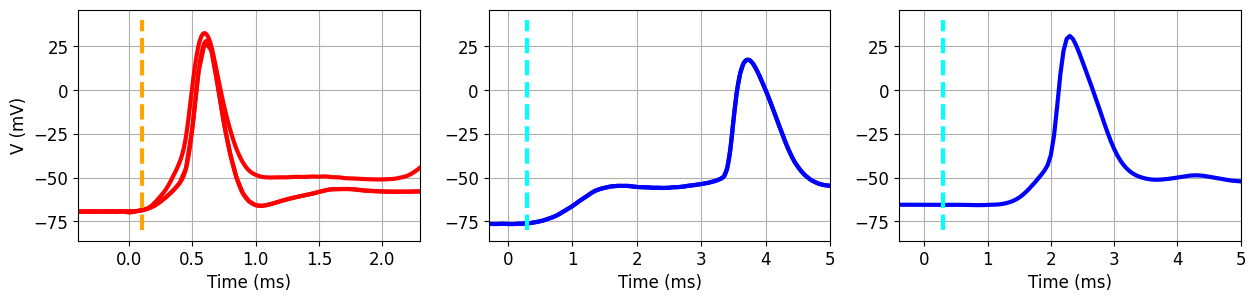

In [105]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
# plt.title("FS: %.2f ms, %.2f ms" %(4.1 - 3.6, 4.3 -3.8))
plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['FS 2 ms stim IC'], color='red', linewidth=3)
plt.plot(t_highres-3.6+0.1, v_highres, color='red', linewidth=3)
plt.plot(t_highres2-3.8+0.1, v_highres2-3, color='red', linewidth=3)
# plt.plot(t_highres2-3.8+300.1, v_highres2-3.0-5, color='black', linewidth=3)
# plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['RS 2 ms stim IC'], color='blue', linewidth=3)
# plt.vlines(x=[3.6, 3.8, 4.1, 4.3, 6.35],ymin=-80, ymax=40, colors='orange', linestyles='dashed')
plt.vlines(x=[0.1],ymin=-80, ymax=40, colors='orange', linestyles='dashed', linewidth=3)
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(-0.4, 2.3)
# plt.ylim(-70, -66)
plt.grid()
plt.subplot(1, 3, 2)
# plt.title("FS: %.2f ms, %.2f ms" %(4.1 - 3.6, 4.3 -3.8))
# plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['FS 2 ms stim IC'], color='red', linewidth=3)
plt.plot(t_highres3-3.6+0.1, v_highres3, color='blue', linewidth=3)
plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['RS 2 ms stim IC'], color='blue', linewidth=3)
plt.vlines(x=[0.3],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
plt.ylabel(' ')
plt.xlabel('Time (ms)')
plt.xlim(-0.3, 5.0)
# plt.ylim(-77, -75)
plt.grid()
plt.subplot(1, 3, 3)
plt.plot(df_rip['102920_DFI_P36']-2.6+0.4, df_rip['RS 2 ms stim'], color='blue', linewidth=3)
plt.vlines(x=[0.3],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
plt.ylabel(' ')
plt.xlabel('Time (ms)')
plt.xlim(-0.4, 5.0)
# plt.ylim(-67, -64)
plt.grid()

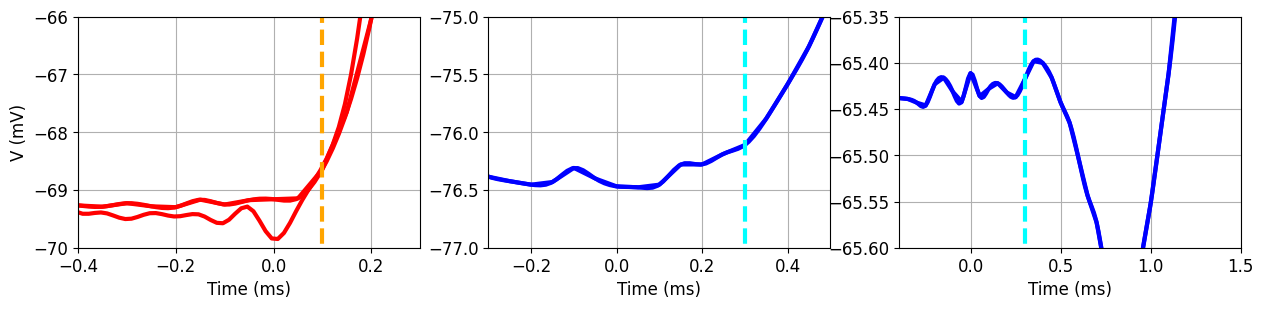

In [25]:
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
# plt.title("FS: %.2f ms, %.2f ms" %(4.1 - 3.6, 4.3 -3.8))
plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['FS 2 ms stim IC'], color='red', linewidth=3)
plt.plot(t_highres-3.6+0.1, v_highres, color='red', linewidth=3)
plt.plot(t_highres2-3.8+0.1, v_highres2-3, color='red', linewidth=3)
# plt.plot(t_highres2-3.8+300.1, v_highres2-3.0-5, color='black', linewidth=3)
# plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['RS 2 ms stim IC'], color='blue', linewidth=3)
# plt.vlines(x=[3.6, 3.8, 4.1, 4.3, 6.35],ymin=-80, ymax=40, colors='orange', linestyles='dashed')
plt.vlines(x=[0.1],ymin=-80, ymax=40, colors='orange', linestyles='dashed', linewidth=3)
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(-0.4, 0.3)
plt.ylim(-70, -66)
plt.grid()
plt.subplot(1, 3, 2)
# plt.title("FS: %.2f ms, %.2f ms" %(4.1 - 3.6, 4.3 -3.8))
# plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['FS 2 ms stim IC'], color='red', linewidth=3)
plt.plot(t_highres3-3.6+0.1, v_highres3, color='blue', linewidth=3)
plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['RS 2 ms stim IC'], color='blue', linewidth=3)
plt.vlines(x=[0.3],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
plt.ylabel(' ')
plt.xlabel('Time (ms)')
plt.xlim(-0.3, 0.5)
plt.ylim(-77, -75)
plt.grid()
plt.subplot(1, 3, 3)
# plt.title("FS: %.2f ms, %.2f ms" %(4.1 - 3.6, 4.3 -3.8))
# plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['FS 2 ms stim IC'], color='red', linewidth=3)
plt.plot(t_highres4-2.6+0.4, v_highres4, color='blue', linewidth=3)
plt.plot(df_rip['102920_DFI_P36']-2.6+0.4, df_rip['RS 2 ms stim'], color='blue', linewidth=3)
plt.vlines(x=[0.3],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
plt.ylabel(' ')
plt.xlabel('Time (ms)')
plt.xlim(-0.4, 1.5)
plt.ylim(-65.6, -65.35)
plt.grid()

Text(0.5, 0, 'Time (ms)')

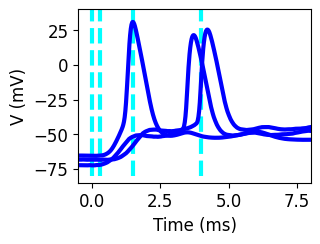

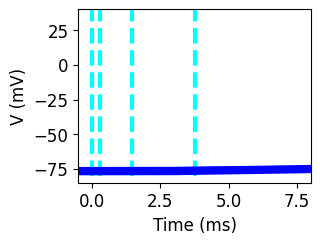

In [26]:
fig = plt.figure(figsize=(3, 2.25))
# plt.plot(df_rip2['042021']-3.6+300.1, df_rip2['FS 2 ms stim IC']-5, color='black')
# plt.plot(df_rip['031820_DFI_P41']-3.8+300.1, df_rip['FS 5 ms stim']-3.0-5, color='black')
plt.vlines(x=[0,0.3,1.5,4.0],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
plt.plot(t_highres3-3.5, v_highres3+4, color='blue', linewidth=3)
plt.plot(t_highres3-3.0, v_highres3+8, color='blue', linewidth=3)
plt.plot(t_highres4-3.0, v_highres4, color='blue', linewidth=3)
# plt.plot(df_rip2['042021']-3.6+0.1, df_rip2['RS 2 ms stim IC'], color='blue', linewidth=3)
# plt.plot(df_rip['102920_DFI_P36']-3.0, df_rip['RS 2 ms stim'], color='blue', linewidth=3)
plt.xlim(-0.5, 8.0)
plt.ylim(-85, 40)
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
fig = plt.figure(figsize=(3, 2.25))
plt.vlines(x=[0,0.3,1.45,3.75],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
plt.plot(sim.simData['t']-300., sim.simData['V_soma']['cell_0']+0, color='blue', linewidth=3)
plt.plot(sim.simData['t']-300., sim.simData['V_soma']['cell_1']+0, color='blue', linewidth=3)
plt.plot(sim.simData['t']-300., sim.simData['V_soma']['cell_2']+0, color='blue', linewidth=3)
plt.plot(sim.simData['t']-300., sim.simData['V_soma']['cell_3']+0, color='blue', linewidth=3)
plt.xlim(-0.5, 8.0)
plt.ylim(-85, 40)
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')

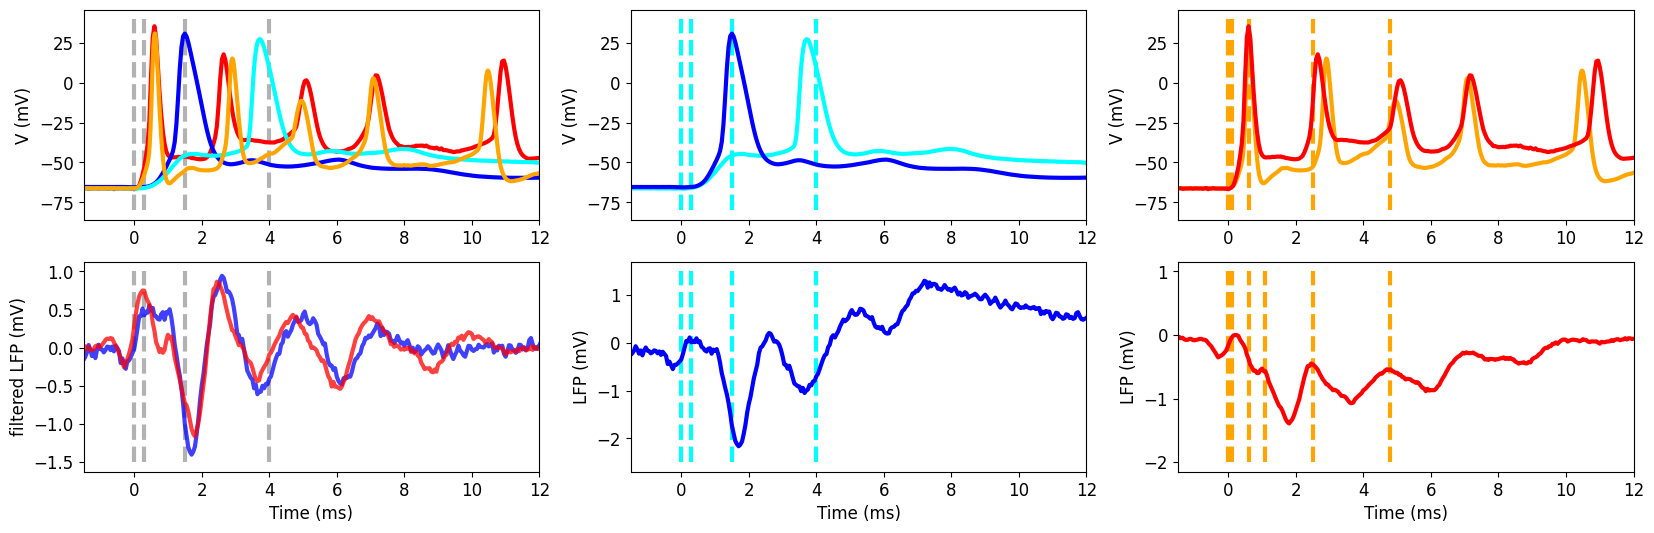

In [27]:
from scipy.signal import butter, filtfilt


# Define high-pass filter parameters
fs = 2000  # Sampling frequency (Hz)
cutoff = 20.0  # Cutoff frequency in Hz
order = 3

# Design Butterworth high-pass filter
b, a = butter(order, cutoff / (0.5 * fs), btype='high', analog=False)

# Apply filter
filtered_signal = filtfilt(b, a, df_rip['Field'].values)
filtered_signal2 = filtfilt(b, a, df_rip['Field.1'].values)

plt.figure(figsize=(20, 6))

plt.subplot(2, 3, 1)
plt.vlines(x=[0,0.3,1.5,4.0],ymin=-80, ymax=40, colors='k', linestyles='dashed', linewidth=3,  alpha=0.3)
plt.plot(df_rip['031820_DFI_P41']-3.8+0.1, df_rip['FS 5 ms stim'], color='red', linewidth=3)
plt.plot(df_rip['102920_DFI_P36']-3.0, df_rip['RS 2 ms stim'], color='blue', linewidth=3)
plt.plot(t_highres3-3.6+0.1, v_highres3+10, color='cyan', linewidth=3)
plt.plot(t_highres-3.6+0.1, v_highres+3, color='orange', linewidth=3)
plt.ylabel('V (mV)')
plt.xlim(-1.5, 12)

plt.subplot(2, 3, 4)
plt.vlines(x=[0,0.3,1.5,4.0],ymin=-1.5, ymax=1.0, colors='k', linestyles='dashed', linewidth=3,  alpha=0.3)
plt.plot(df_rip['102920_DFI_P36']-3.0, 1*filtered_signal2, color='blue', linewidth=3,  alpha=0.75)
plt.plot(df_rip['031820_DFI_P41']-3.8+0.1, 2*filtered_signal, color='red', linewidth=3,  alpha=0.75)
plt.ylabel('filtered LFP (mV)')
plt.xlabel('Time (ms)')
plt.xlim(-1.5, 12)

plt.subplot(2, 3, 2)
plt.vlines(x=[0,0.3,1.5,4.0],ymin=-80, ymax=40, colors='cyan', linestyles='dashed', linewidth=3)
plt.plot(t_highres3-3.6+0.1, v_highres3+10, color='cyan', linewidth=3)
plt.plot(df_rip['102920_DFI_P36']-3.0, df_rip['RS 2 ms stim'], color='blue', linewidth=3)
plt.ylabel('V (mV)')
plt.xlim(-1.5, 12)

plt.subplot(2, 3, 5)
plt.vlines(x=[0,0.3,1.5,4.0],ymin=-2.5, ymax=1.5, colors='cyan', linestyles='dashed', linewidth=3)
plt.plot(df_rip['102920_DFI_P36']-3.0, df_rip['Field.1'], color='blue', linewidth=3)
plt.ylabel('LFP (mV)')
plt.xlabel('Time (ms)')
plt.xlim(-1.5, 12)

plt.subplot(2, 3, 3)
plt.vlines(x=[0,0.1,0.6,2.5,4.8],ymin=-80, ymax=40, colors='orange', linestyles='dashed', linewidth=3)
plt.plot(t_highres-3.6+0.1, v_highres+3, color='orange', linewidth=3)
plt.plot(df_rip['031820_DFI_P41']-3.8+0.1, df_rip['FS 5 ms stim'], color='red', linewidth=3)
plt.ylabel('V (mV)')
plt.xlim(-1.5, 12)
plt.subplot(2, 3, 6)
plt.vlines(x=[0,0.1,0.6,1.1,2.5,4.8],ymin=-2, ymax=1, colors='orange', linestyles='dashed', linewidth=3)
plt.plot(df_rip['031820_DFI_P41']-3.8+0.1, df_rip['Field'], color='red', linewidth=3)
plt.ylabel('LFP (mV)')
plt.xlabel('Time (ms)')
plt.xlim(-1.5, 12);


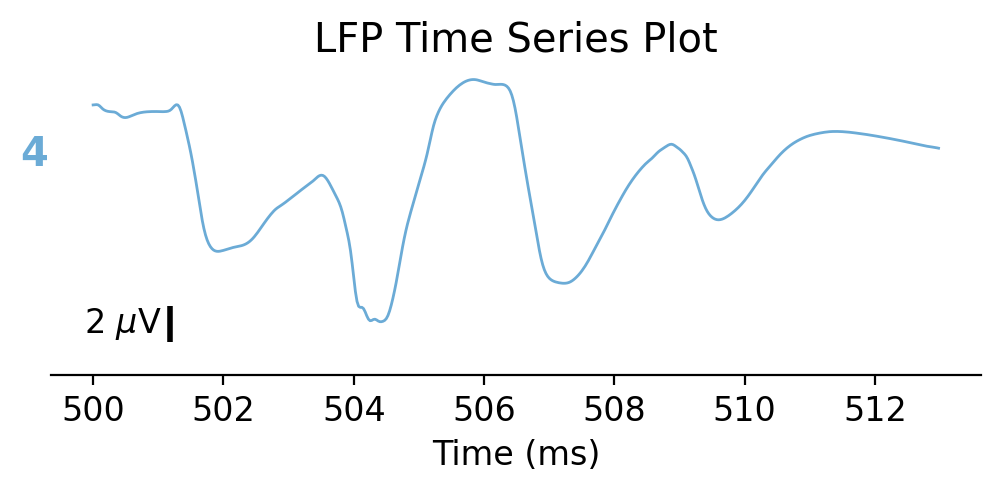

(2.0, 10.0)

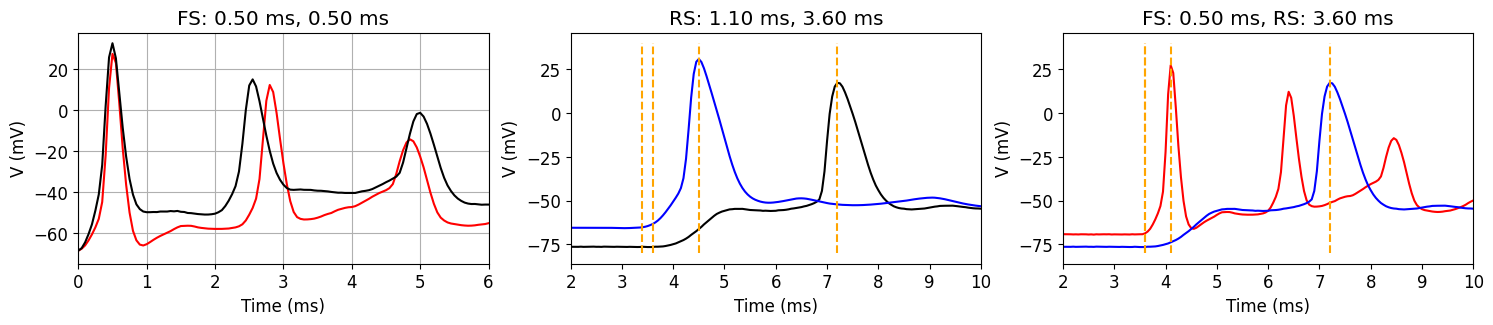

In [28]:
plt.figure(figsize=(18, 3))
plt.subplot(1, 3, 1)
plt.title("FS: %.2f ms, %.2f ms" %(4.1 - 3.6, 4.3 -3.8))
plt.plot(df_rip2['042021']-3.6, df_rip2['FS 2 ms stim IC'], color='red')
plt.plot(df_rip['031820_DFI_P41']-3.8, df_rip['FS 5 ms stim']-3.0, color='black')
# plt.vlines(x=[3.6, 3.8, 4.1, 4.3, 6.35],ymin=-80, ymax=40, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(0, 6)
plt.grid()
# plt.ylim(-69.5, -64.1)
plt.subplot(1, 3, 2)
plt.title("RS: %.2f ms, %.2f ms" %(4.5 - 3.4, 7.2 -3.6))
plt.plot(df_rip2['042021'], df_rip2['RS 2 ms stim IC'], color='k')
plt.plot(df_rip['102920_DFI_P36'], df_rip['RS 2 ms stim'], color='blue')
plt.vlines(x=[3.4, 4.5, 3.6, 7.2],ymin=-80, ymax=40, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(2.0, 10)
# plt.ylim(-78.0, -64.1)
plt.subplot(1, 3, 3)
plt.title("FS: %.2f ms, RS: %.2f ms" %(4.1 - 3.6, 7.2 - 3.6))
plt.plot(df_rip2['042021'], df_rip2['FS 2 ms stim IC'], color='red')
plt.plot(df_rip2['042021'], df_rip2['RS 2 ms stim IC'], color='blue')
plt.vlines(x=[3.6, 4.1, 3.6, 7.2],ymin=-80, ymax=40, colors='orange', linestyles='dashed')
plt.ylabel('V (mV)')
plt.xlabel('Time (ms)')
plt.xlim(2.0, 10)